# Analyse des utilisateurs JSONPlaceholder

Ce notebook se connecte à PostgreSQL, exécute les requêtes SQL demandées et crée les deux visualisations. Les coordonnées stockées proviennent de `address.geo` dans l'API.

In [1]:
import os
from pathlib import Path
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import folium
from IPython.display import display

plt.style.use('seaborn-v0_8-whitegrid')
connexion = psycopg2.connect(
    host=os.getenv('DB_HOST', '127.0.0.1'), port=int(os.getenv('DB_PORT', '55432')),
    dbname=os.getenv('DB_NAME', 'collecte'), user=os.getenv('DB_USER', 'collecte'),
    password=os.getenv('DB_PASSWORD', 'collecte')
)
print('Connexion PostgreSQL établie.')

Connexion PostgreSQL établie.


## 1. Nombre total d'utilisateurs

In [2]:
with connexion.cursor() as curseur:
    curseur.execute('SELECT COUNT(*) FROM utilisateurs')
    total = curseur.fetchone()[0]
print(f"Nombre total d'utilisateurs : {total}")

Nombre total d'utilisateurs : 10


## 2. Utilisateurs ayant une adresse `.net` ou `.biz`

In [3]:
requete_domaines = '''
SELECT id, nom, email, ville
FROM utilisateurs
WHERE LOWER(email) LIKE '%.net' OR LOWER(email) LIKE '%.biz'
ORDER BY id
'''
utilisateurs_filtres = pd.read_sql_query(requete_domaines, connexion)
display(utilisateurs_filtres)

C:\Users\khadi\AppData\Local\Temp\ipykernel_28896\3374453249.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  utilisateurs_filtres = pd.read_sql_query(requete_domaines, connexion)


,id,nom,email,ville
0,1,Leanne Graham,Sincere@april.biz,Gwenborough
1,3,Clementine Bauch,Nathan@yesenia.net,McKenziehaven
2,7,Kurtis Weissnat,Telly.Hoeger@billy.biz,Howemouth
3,10,Clementina DuBuque,Rey.Padberg@karina.biz,Lebsackbury


## 3. Capture de la table SQL remplie

C:\Users\khadi\AppData\Local\Temp\ipykernel_28896\2657761939.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  utilisateurs = pd.read_sql_query('SELECT * FROM utilisateurs ORDER BY id', connexion)


,id,nom,email,ville,latitude,longitude
0,1,Leanne Graham,Sincere@april.biz,Gwenborough,-37.3159,81.1496
1,2,Ervin Howell,Shanna@melissa.tv,Wisokyburgh,-43.9509,-34.4618
2,3,Clementine Bauch,Nathan@yesenia.net,McKenziehaven,-68.6102,-47.0653
3,4,Patricia Lebsack,Julianne.OConner@kory.org,South Elvis,29.4572,-164.2990
4,5,Chelsey Dietrich,Lucio_Hettinger@annie.ca,Roscoeview,-31.8129,62.5342
5,6,Mrs. Dennis Schulist,Karley_Dach@jasper.info,South Christy,-71.4197,71.7478
6,7,Kurtis Weissnat,Telly.Hoeger@billy.biz,Howemouth,24.8918,21.8984
7,8,Nicholas Runolfsdottir V,Sherwood@rosamond.me,Aliyaview,-14.3990,-120.7677
8,9,Glenna Reichert,Chaim_McDermott@dana.io,Bartholomebury,24.6463,-168.8889
9,10,Clementina DuBuque,Rey.Padberg@karina.biz,Lebsackbury,-38.2386,57.2232


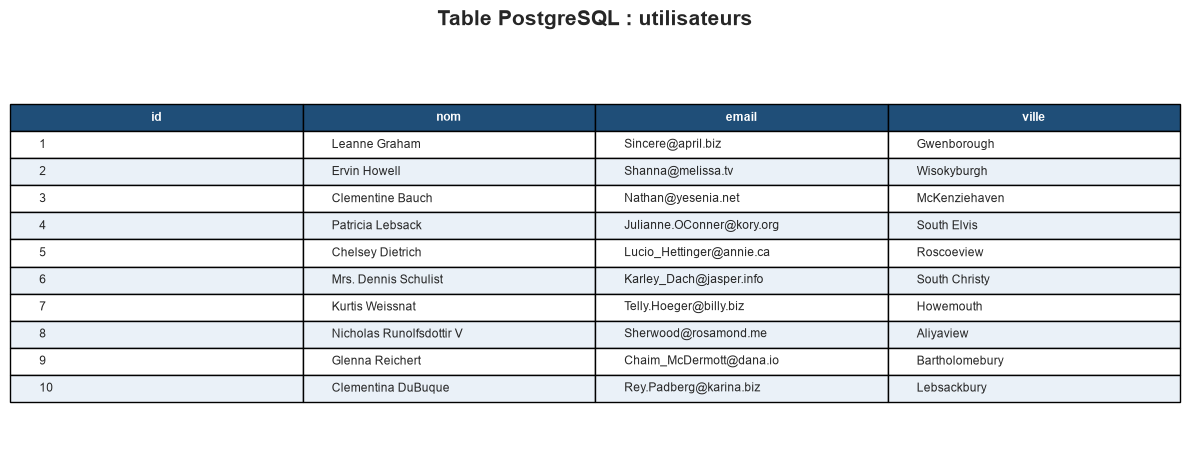

In [4]:
utilisateurs = pd.read_sql_query('SELECT * FROM utilisateurs ORDER BY id', connexion)
display(utilisateurs)

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.axis('off')
table = ax.table(cellText=utilisateurs[['id','nom','email','ville']].values,
                 colLabels=['id','nom','email','ville'], loc='center', cellLoc='left')
table.auto_set_font_size(False); table.set_fontsize(8.5); table.scale(1, 1.45)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#1F4E78'); cell.set_text_props(color='white', weight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#EAF1F8')
ax.set_title('Table PostgreSQL : utilisateurs', fontsize=15, weight='bold', pad=15)
plt.tight_layout(); plt.savefig('table_sql.png', dpi=180, bbox_inches='tight'); plt.show()

## 4. Graphique des extensions d'adresses e-mail

extension
.biz     3
.tv      1
.net     1
.org     1
.ca      1
.info    1
.me      1
.io      1
Name: nombre, dtype: int64

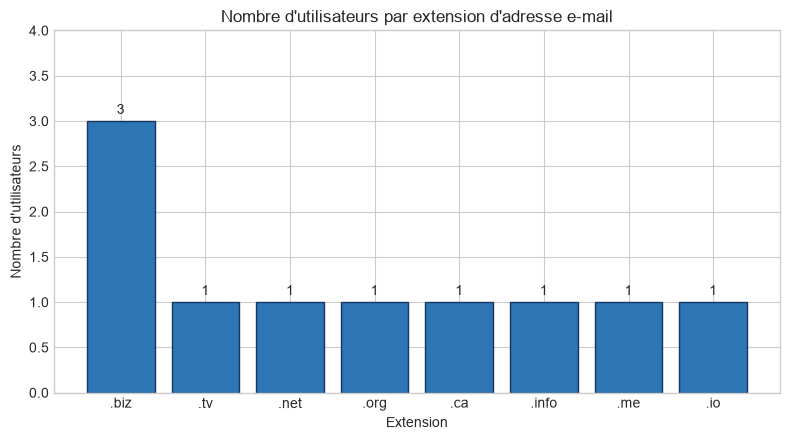

In [5]:
utilisateurs['extension'] = utilisateurs['email'].str.lower().str.extract(r'(\.[a-z]+)$')
extensions = utilisateurs['extension'].value_counts().sort_values(ascending=False)
display(extensions.rename('nombre'))

fig, ax = plt.subplots(figsize=(8, 4.5))
barres = ax.bar(extensions.index, extensions.values, color='#2E75B6', edgecolor='#17365D')
ax.bar_label(barres, padding=3)
ax.set(title="Nombre d'utilisateurs par extension d'adresse e-mail", xlabel='Extension', ylabel="Nombre d'utilisateurs")
ax.set_ylim(0, max(extensions.values) + 1)
plt.tight_layout(); plt.savefig('extensions_email.png', dpi=180, bbox_inches='tight'); plt.show()

**Commentaire.** L'extension `.biz` est la plus fréquente (3 utilisateurs). Les sept autres extensions représentées apparaissent une seule fois ; `.net` concerne un utilisateur.

## 5. Carte interactive des utilisateurs

In [6]:
centre = [utilisateurs['latitude'].mean(), utilisateurs['longitude'].mean()]
carte = folium.Map(location=centre, zoom_start=2, tiles='OpenStreetMap')
for ligne in utilisateurs.itertuples():
    folium.Marker(
        [ligne.latitude, ligne.longitude],
        popup=folium.Popup(f'<b>{ligne.nom}</b><br>{ligne.ville}', max_width=250),
        tooltip=f'{ligne.nom} — {ligne.ville}'
    ).add_to(carte)
carte.fit_bounds([[utilisateurs.latitude.min(), utilisateurs.longitude.min()],
                  [utilisateurs.latitude.max(), utilisateurs.longitude.max()]])
carte.save('map_utilisateurs.html')
carte

**Commentaire.** Les marqueurs sont dispersés sur plusieurs continents. Ces coordonnées sont des données de démonstration de JSONPlaceholder et ne doivent pas être interprétées comme des adresses réelles.

In [7]:
connexion.close(); print('Connexion fermée.')

Connexion fermée.
